In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')
import os

#### read the input data

In [ ]:
#import the csv file
bike_df=pd.read_csv("../datasets/day.csv")

In [ ]:
bike_df.shape

(731, 16)

In [ ]:
#Data types
bike_df.dtypes

,0
instant,int64
dteday,object
season,int64
yr,int64
mnth,int64
holiday,int64
weekday,int64
workingday,int64
weathersit,int64
temp,float64


In [ ]:
bike_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [ ]:
bike_df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


#### Rename the columns for better understanding of variables

In [ ]:
#Rename the columns
bike_df.rename(columns={'instant':'rec_id','dteday':'datetime','yr':'year','mnth':'month','weathersit':'weather_condition',
                       'hum':'humidity','cnt':'total_count'},inplace=True)


In [ ]:
bike_df.head(5)

,rec_id,datetime,season,year,month,holiday,weekday,workingday,weather_condition,temp,atemp,humidity,windspeed,casual,registered,total_count
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [ ]:
#Type casting the datetime and numerical attributes to category

bike_df['datetime']=pd.to_datetime(bike_df.datetime)

bike_df['season']=bike_df.season.astype('category')
bike_df['year']=bike_df.year.astype('category')
bike_df['month']=bike_df.month.astype('category')
bike_df['holiday']=bike_df.holiday.astype('category')
bike_df['weekday']=bike_df.weekday.astype('category')
bike_df['workingday']=bike_df.workingday.astype('category')
bike_df['weather_condition']=bike_df.weather_condition.astype('category')

In [ ]:
bike_df.dtypes

,0
rec_id,int64
datetime,datetime64[ns]
season,category
year,category
month,category
holiday,category
weekday,category
workingday,category
weather_condition,category
temp,float64


In [ ]:
#Summary of the dataset
bike_df.describe()

,rec_id,datetime,temp,atemp,humidity,windspeed,casual,registered,total_count
count,731.000000,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2012-01-01 00:00:00,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
min,1.000000,2011-01-01 00:00:00,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2011-07-02 12:00:00,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,2012-01-01 00:00:00,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,2012-07-01 12:00:00,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,2012-12-31 00:00:00,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000
std,211.165812,NaN,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452


#### Missing value analysis

In [ ]:
#Missing values in dataset
bike_df.isnull().sum()

,0
rec_id,0
datetime,0
season,0
year,0
month,0
holiday,0
weekday,0
workingday,0
weather_condition,0
temp,0


No missing values present in training dataset.

### Attributes distributions and trends

#### Monthly distribution of counts

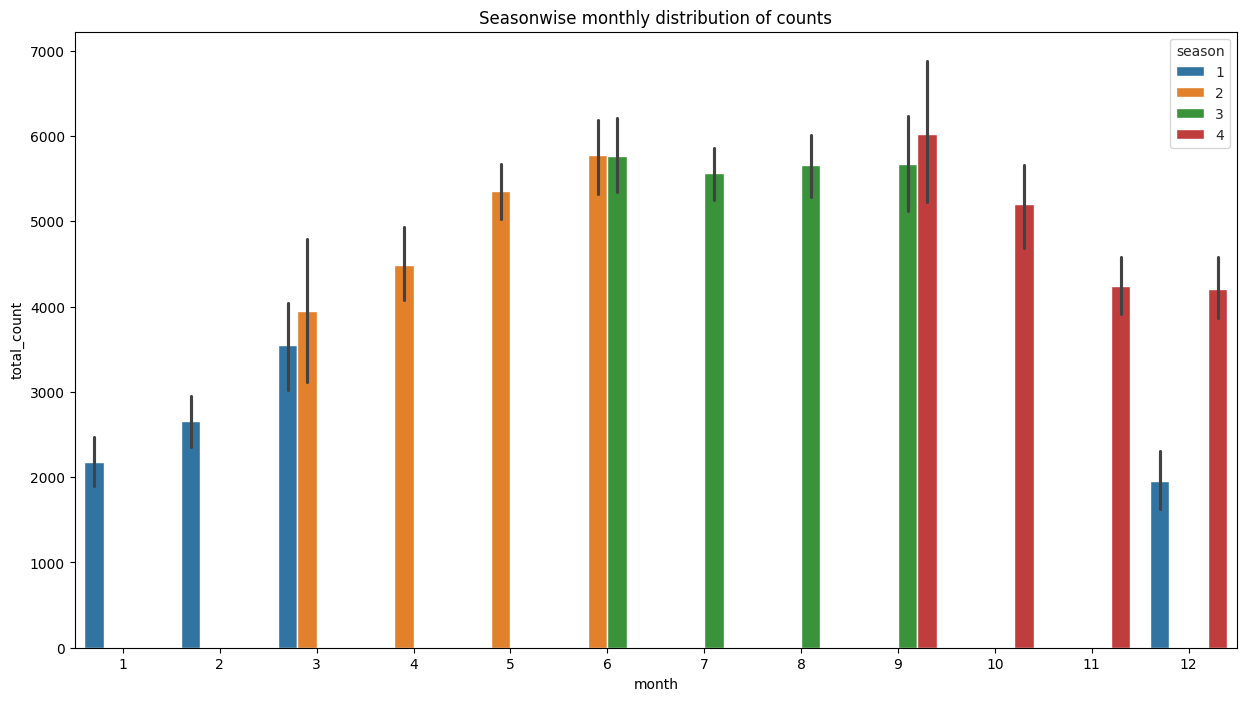

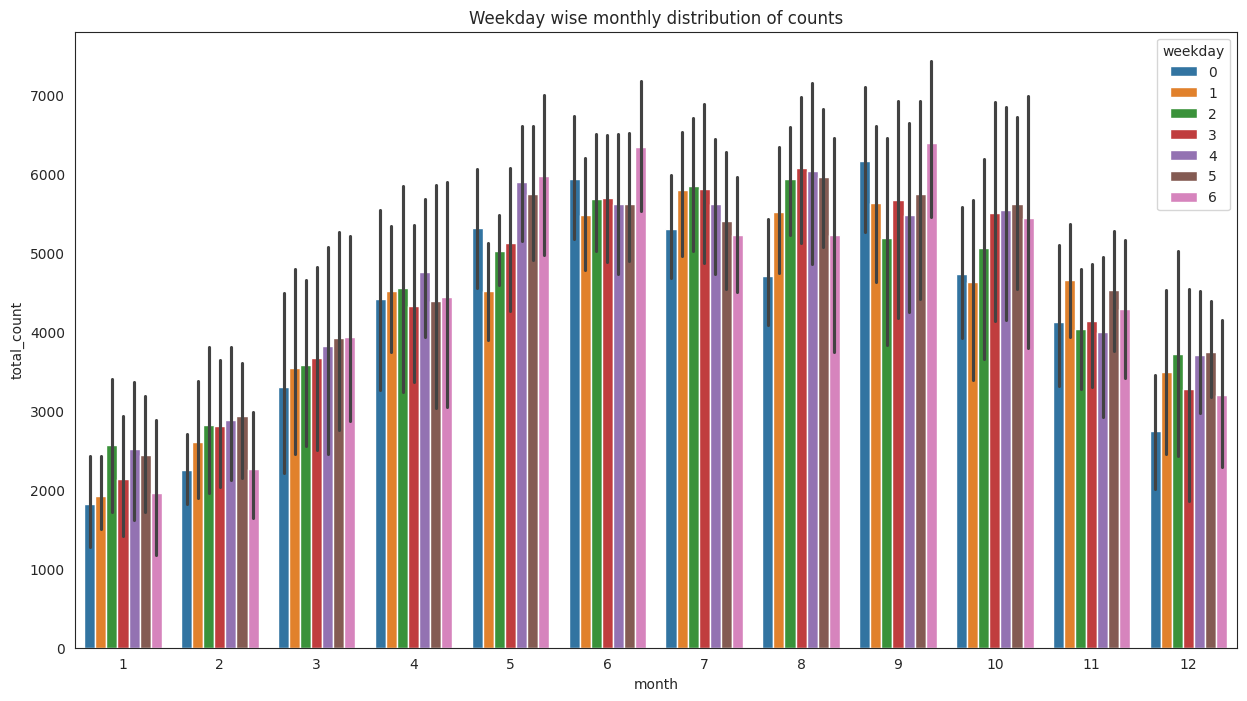

In [ ]:


fig,ax=plt.subplots(figsize=(15,8))
sns.set_style('white')
#Bar plot for seasonwise monthly distribution of counts
sns.barplot(x='month',y='total_count',data=bike_df[['month','total_count','season']],hue='season',ax=ax)
ax.set_title('Seasonwise monthly distribution of counts')
plt.show()
#Bar plot for weekday wise monthly distribution of counts
fig,ax1=plt.subplots(figsize=(15,8))
sns.barplot(x='month',y='total_count',data=bike_df[['month','total_count','weekday']],hue='weekday',ax=ax1)
ax1.set_title('Weekday wise monthly distribution of counts')
plt.show()

From the above plots, we can observed that increasing the bike rental count in springe and summer season and then decreasing the bike rental count in fall and winter season. Here,

season 1-> spring season 2 -> summer season 3 -> fall season 4 -> winter

#### Yearly wise distribution of counts


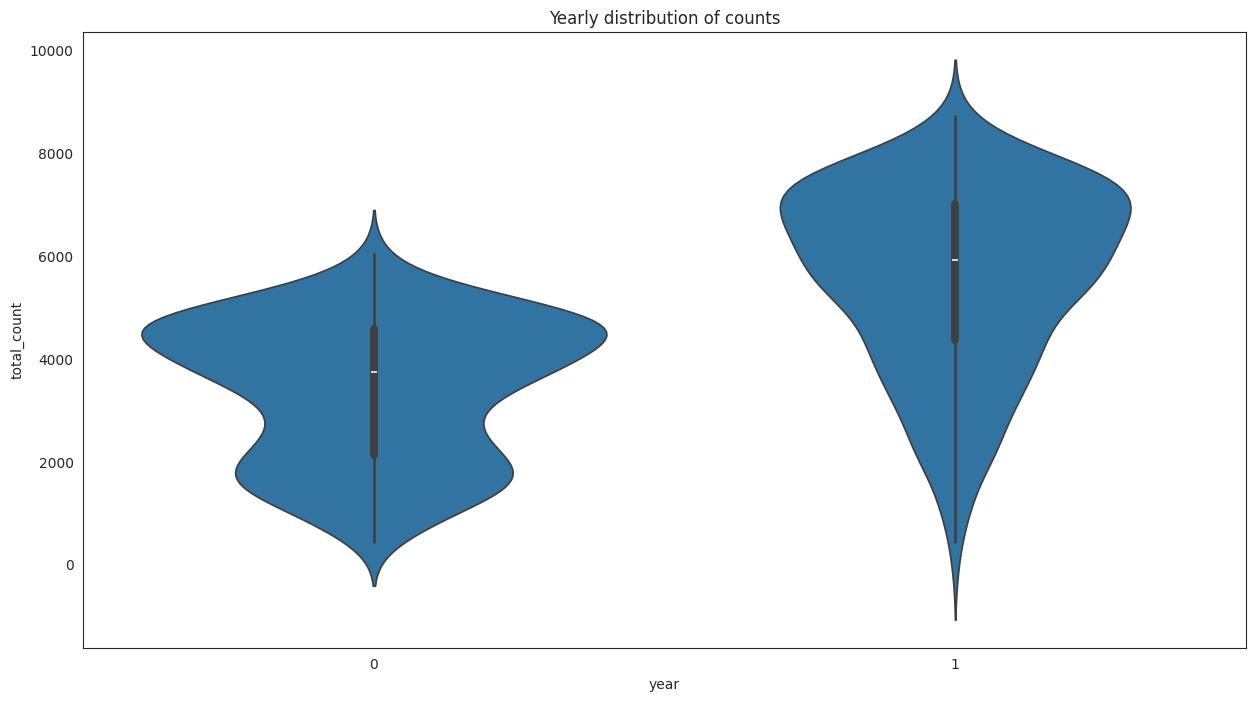

In [ ]:

fig,ax=plt.subplots(figsize=(15,8))
#Violin plot for yearly distribution of counts
sns.violinplot(x='year',y='total_count',data=bike_df[['year','total_count']])
ax.set_title('Yearly distribution of counts')
plt.show()

#### Holiday wise distribution of counts

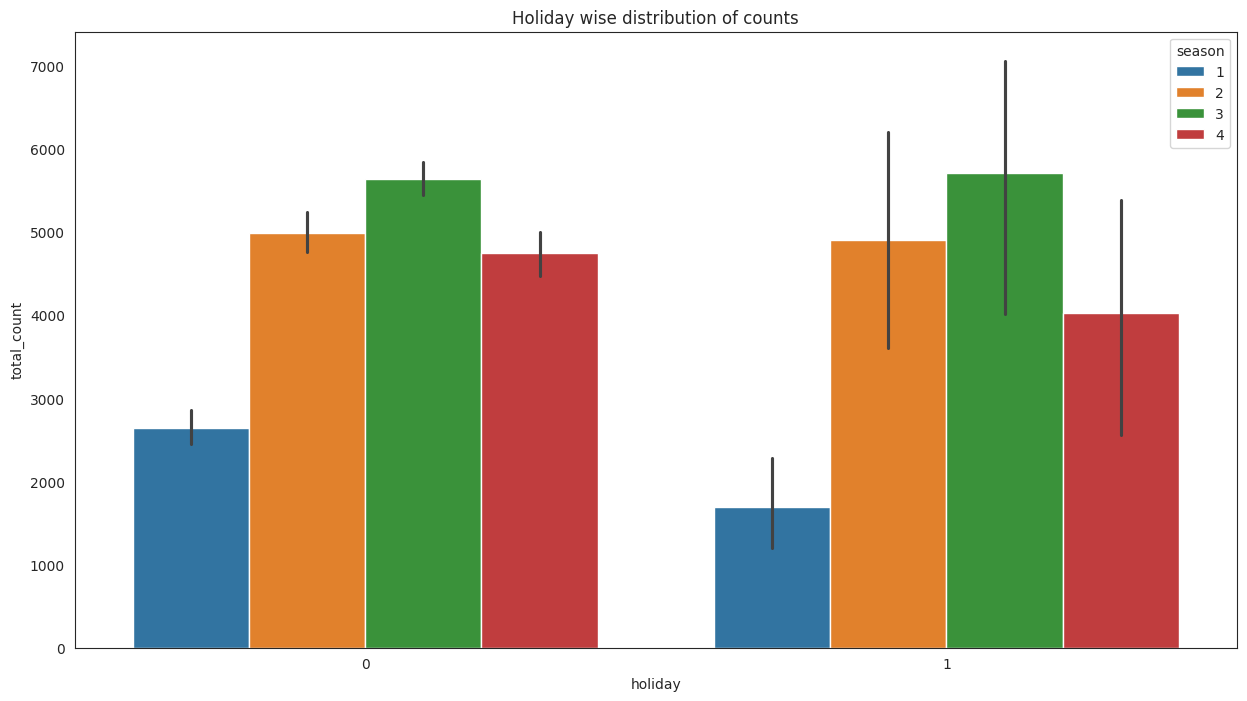

In [ ]:


fig,ax=plt.subplots(figsize=(15,8))
#Barplot for Holiday distribution of counts
sns.barplot(data=bike_df,x='holiday',y='total_count',hue='season')
ax.set_title('Holiday wise distribution of counts')
plt.show()

From the above bar plot, we can observed that during workingday the bike rental counts is quite highest compared to during no workingday for different seasons.

Here, 0-> No workingday, 1-> workingday



### Weather_condition distribution of counts

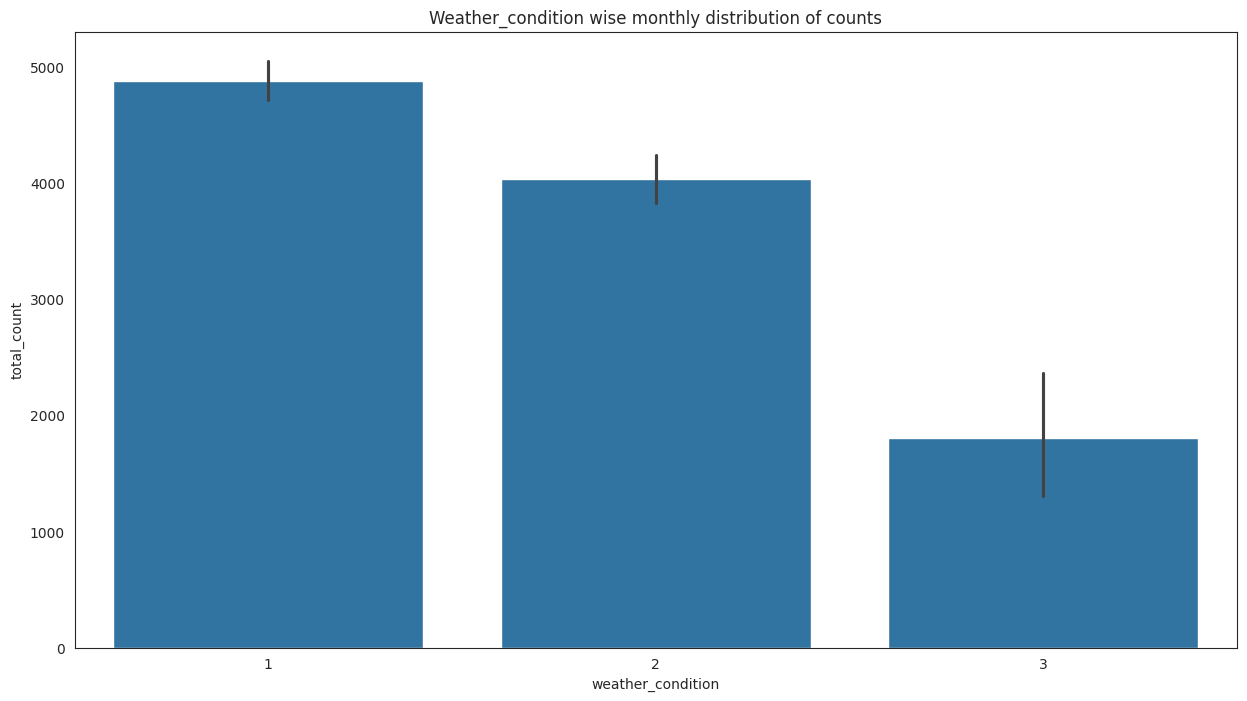

In [ ]:
fig,ax1=plt.subplots(figsize=(15,8))
#Bar plot for weather_condition distribution of counts
sns.barplot(x='weather_condition',y='total_count',data=bike_df[['month','total_count','weather_condition']],ax=ax1)
ax1.set_title('Weather_condition wise monthly distribution of counts')
plt.show()


From the above bar plot, we can observed that during clear,partly cloudy weather the bike rental count is highest and the second highest is during mist cloudy weather and followed by third highest during light snow and light rain weather.

#### Outlier analysis

#### Total_Count_Outliers

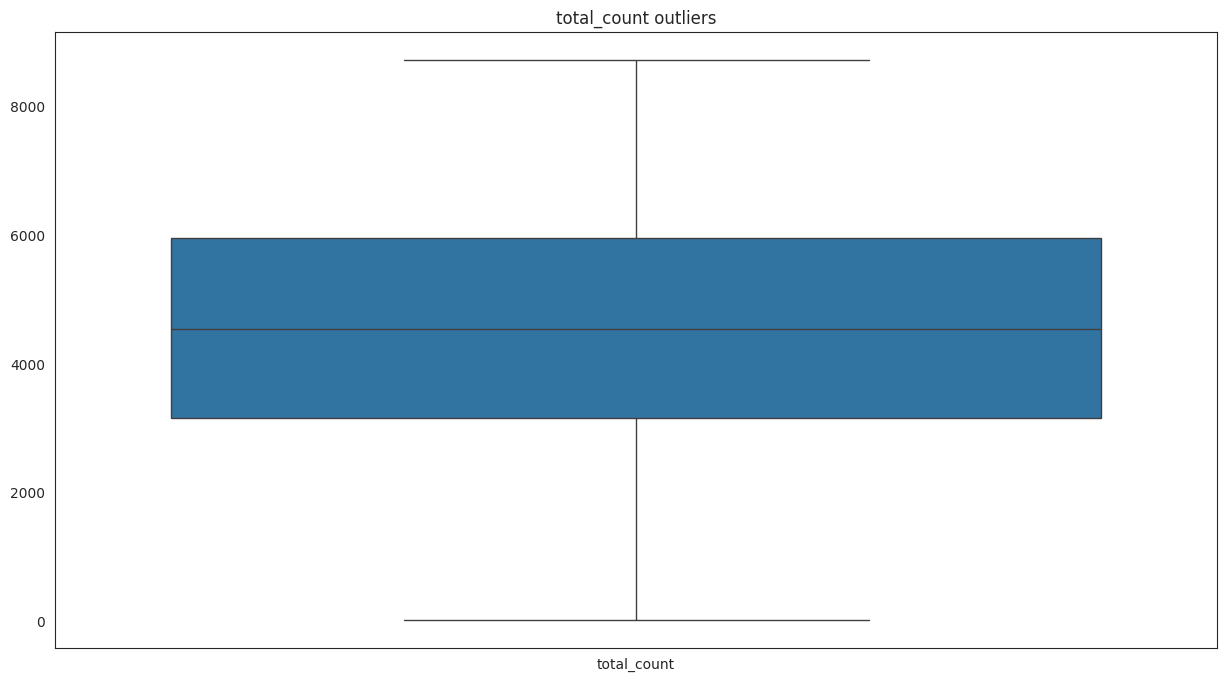

In [ ]:


fig,ax=plt.subplots(figsize=(15,8))
#Boxplot for total_count outliers
sns.boxplot(data=bike_df[['total_count']])
ax.set_title('total_count outliers')
plt.show()

From the box plot, we can observed that no outliers are present in total_count variable.

### Temp_windspeed_humidity_outliers

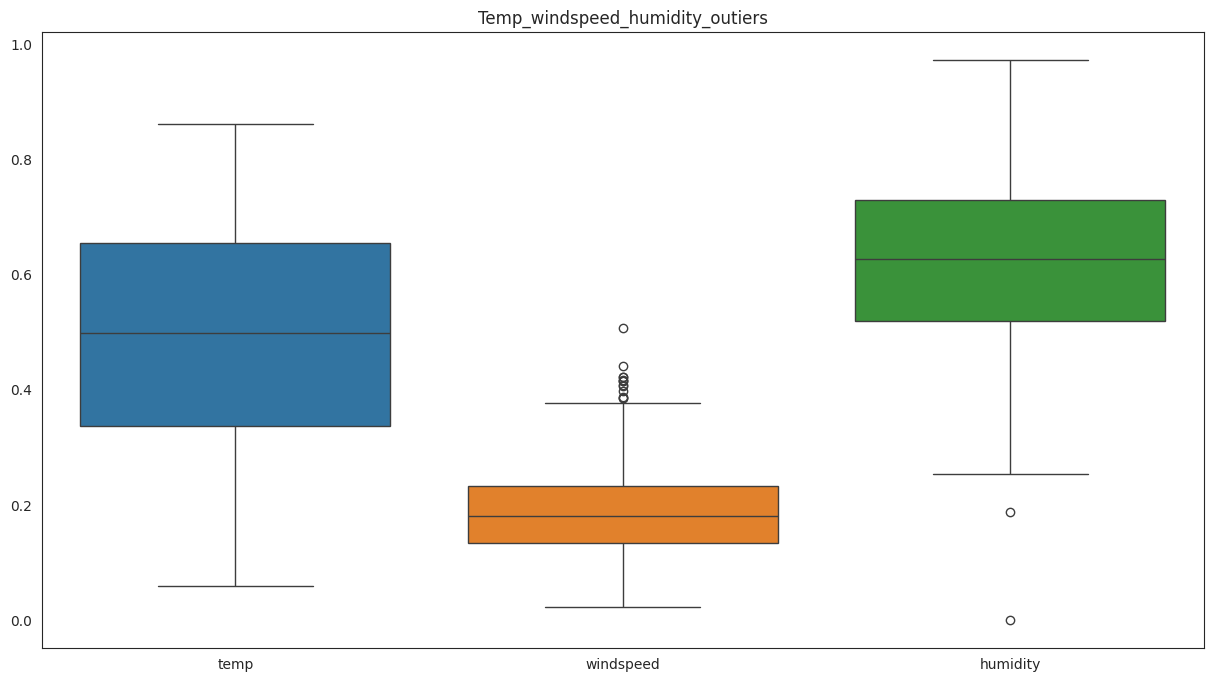

In [ ]:


fig,ax=plt.subplots(figsize=(15,8))
#Box plot for Temp_windspeed_humidity_outliers
sns.boxplot(data=bike_df[['temp','windspeed','humidity']])
ax.set_title('Temp_windspeed_humidity_outiers')
plt.show()

From the box plot, we can observed that no outliers are present in normalized temp but few outliers are present in normalized windspeed and humidity variable.

#### Replace and impute the outliers

In [ ]:
## replace outliers with mean

#create dataframe for outliers
wind_hum=pd.DataFrame(bike_df,columns=['windspeed','humidity'])
 #Cnames for outliers
cnames=['windspeed','humidity']

for i in cnames:
    q75,q25=np.percentile(wind_hum.loc[:,i],[75,25]) # Divide data into 75%quantile and 25%quantile.
    iqr=q75-q25 #Inter quantile range
    min=q25-(iqr*1.5) #inner fence
    max=q75+(iqr*1.5) #outer fence
    wind_hum.loc[wind_hum.loc[:,i]<min,:i]=np.nan  #Replace with NA
    wind_hum.loc[wind_hum.loc[:,i]>max,:i]=np.nan  #Replace with NA
#Imputating the outliers by mean Imputation
wind_hum['windspeed']=wind_hum['windspeed'].fillna(wind_hum['windspeed'].mean())
wind_hum['humidity']=wind_hum['humidity'].fillna(wind_hum['humidity'].mean())

### Replace the original dataset to imputated data

In [ ]:
#Replacing the imputated windspeed
bike_df['windspeed']=bike_df['windspeed'].replace(wind_hum['windspeed'])
#Replacing the imputated humidity
bike_df['humidity']=bike_df['humidity'].replace(wind_hum['humidity'])
bike_df.head(5)

,rec_id,datetime,season,year,month,holiday,weekday,workingday,weather_condition,temp,atemp,humidity,windspeed,casual,registered,total_count
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


### Normal Probability Plot

Normal probability plot is a graphical technique to identify substantive departures from normality and also it tells about goodness of fit.


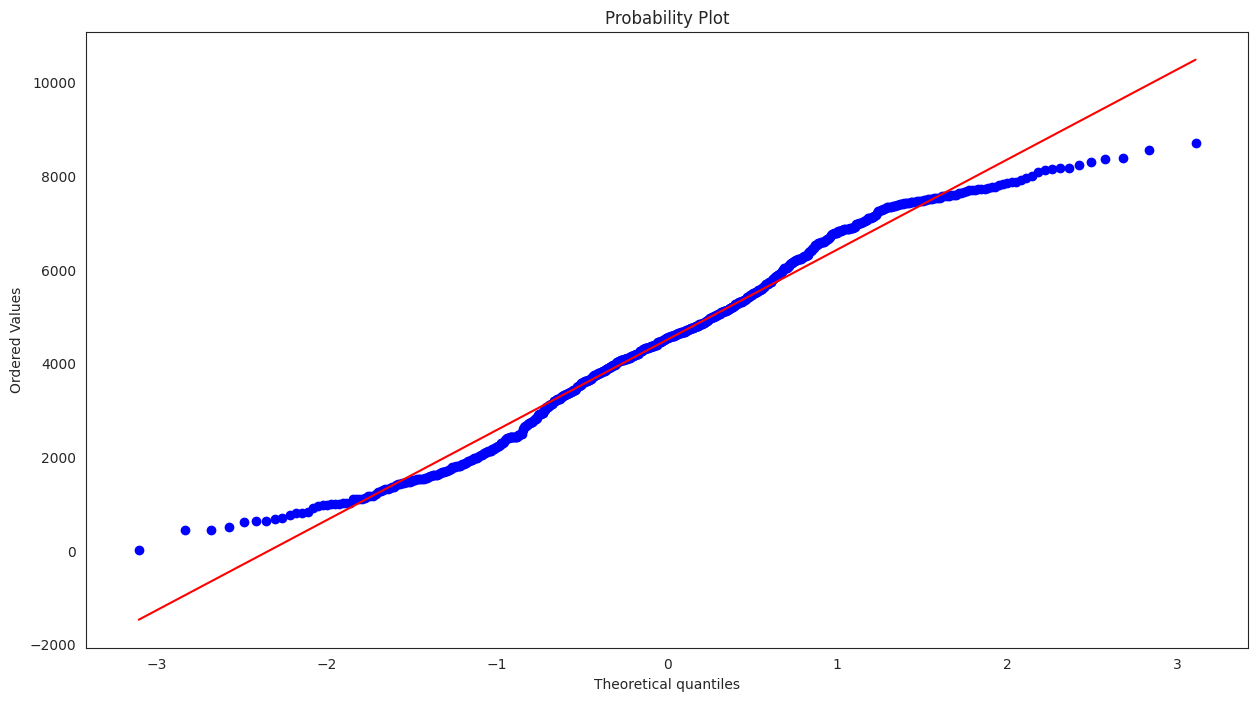

In [ ]:
import scipy
from scipy import stats
#Normal plot
fig=plt.figure(figsize=(15,8))
stats.probplot(bike_df.total_count.tolist(),dist='norm',plot=plt)
plt.show()

The above probability plot, the some target variable data points are deviates from normality.



### Correlation matrix

Correlation matrix is tells about linear relationship between attributes and help us to build better models.

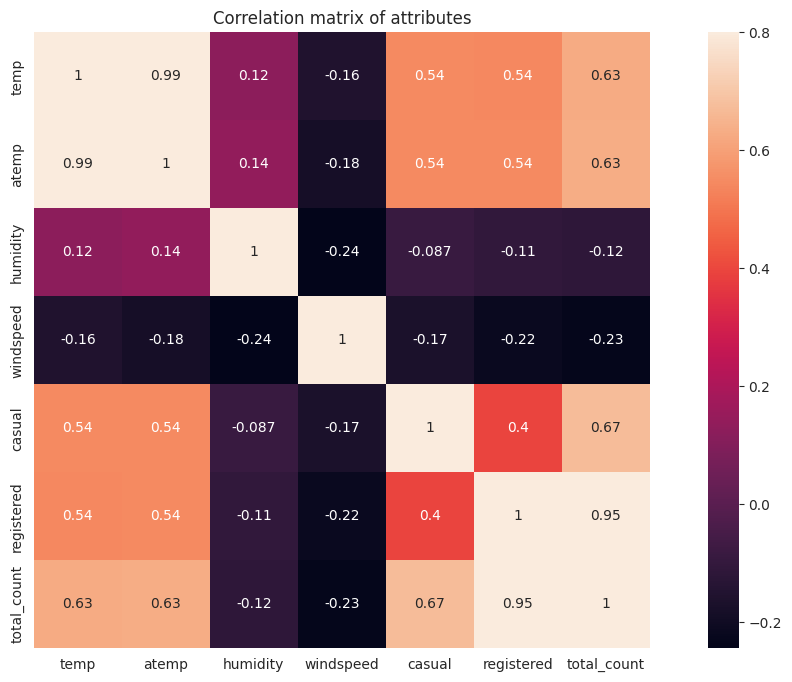

In [ ]:
#Create the correlation matrix
correMtr=bike_df[["temp","atemp","humidity","windspeed","casual","registered","total_count"]].corr()

#Heat map for correlation matrix of attributes
fig,ax=plt.subplots(figsize=(15,8))
sns.heatmap(correMtr,vmax=0.8,square=True,annot=True,ax=ax)
ax.set_title('Correlation matrix of attributes')
plt.show()

From correlation plot, we can observed that some features are positively correlated or some are negatively correlated to each other. The temp and atemp are highly positively correlated to each other, it means that both are carrying same information.The total_count,casual and registered are highly positively correlated to each other. So, we are going to ignore atemp,casual and registered variable for further analysis.

### Modelling the dataset

In [ ]:
#load the required libraries
from sklearn import preprocessing,metrics,linear_model
from sklearn.model_selection import cross_val_score,cross_val_predict,train_test_split

In [ ]:
#Split the dataset into the train and test data
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(bike_df.iloc[:,0:-3],bike_df.iloc[:,-1],test_size=0.3, random_state=42)

#Reset train index values
X_train.reset_index(inplace=True)
y_train=y_train.reset_index()

# Reset train index values
X_test.reset_index(inplace=True)
y_test=y_test.reset_index()

print(X_train.shape,X_test.shape,y_train.shape,y_test.shape)
print(y_train.head())
print(y_test.head())


(511, 14) (220, 14) (511, 2) (220, 2)
   index  total_count
0    223         4905
1    684         5445
2    685         5698
3    163         5020
4    394         3624
   index  total_count
0    703         6606
1     33         1550
2    300         3747
3    456         6041
4    633         7538


In [ ]:
X_train.head()

,index,rec_id,datetime,season,year,month,holiday,weekday,workingday,weather_condition,temp,atemp,humidity,windspeed
0,223,224,2011-08-12,3,0,8,0,5,1,1,0.708333,0.654042,0.415000,0.125621
1,684,685,2012-11-15,4,1,11,0,4,1,2,0.321667,0.324492,0.620417,0.152987
2,685,686,2012-11-16,4,1,11,0,5,1,1,0.345000,0.347204,0.524583,0.171025
3,163,164,2011-06-13,2,0,6,0,1,1,1,0.635000,0.601654,0.494583,0.305350
4,394,395,2012-01-30,1,1,1,0,1,1,1,0.269167,0.262625,0.400833,0.215792


#### Split the features into categorical and numerical features

In [ ]:
#Create a new dataset for train attributes
train_attributes=X_train[['season','month','year','weekday','holiday','workingday','weather_condition','humidity','temp','windspeed']]
#Create a new dataset for test attributes
test_attributes= X_test[['season','month','year','weekday','holiday','workingday','humidity','temp','windspeed','weather_condition']]
#categorical attributes
cat_attributes=['season','holiday','workingday','weather_condition','year']
#numerical attributes
num_attributes=['temp','windspeed','humidity','month','weekday']


#### Encoding the training attributes

In [ ]:
#encode the categorical features to numeric
train_encoded_attributes=pd.get_dummies(train_attributes,columns=cat_attributes, dtype=int )
print('Shape of transfomed dataframe::',train_encoded_attributes.shape)
train_encoded_attributes.head(5)



test_encoded_attributes=pd.get_dummies(test_attributes,columns=cat_attributes, dtype=int )
print('Shape of transfomed dataframe::',test_encoded_attributes.shape)
test_encoded_attributes.head(5)

Shape of transfomed dataframe:: (511, 18)
Shape of transfomed dataframe:: (220, 18)


,month,weekday,humidity,temp,windspeed,season_1,season_2,season_3,season_4,holiday_0,holiday_1,workingday_0,workingday_1,weather_condition_1,weather_condition_2,weather_condition_3,year_0,year_1
0,12,2,0.733750,0.475833,0.174129,0,0,0,1,1,0,0,1,1,0,0,0,1
1,2,4,0.437826,0.186957,0.277752,1,0,0,0,1,0,0,1,1,0,0,1,0
2,10,5,0.585833,0.330833,0.229479,0,0,0,1,1,0,0,1,0,1,0,1,0
3,4,0,0.676250,0.425833,0.172267,0,1,0,0,1,0,1,0,0,1,0,0,1
4,9,2,0.570000,0.550000,0.236321,0,0,0,1,1,0,0,1,1,0,0,0,1


#### Training dataset


In [ ]:
#dataset for modelling
X_train=train_encoded_attributes
y_train=y_train.total_count.values

In [ ]:
X_test = test_encoded_attributes
y_test = y_test.total_count.values

## Linear Regression Model

In [ ]:
#training model
lr_model=linear_model.LinearRegression()
lr_model

LinearRegression()

In [ ]:
#fit the trained model
lr_model.fit(X_train,y_train)

LinearRegression()

In [ ]:
# Predict on training data
y_train_pred = lr_model.predict(X_train)

# Calculate metrics for training data
rmse_train = np.sqrt(metrics.mean_squared_error(y_train, y_train_pred))
mae_train = metrics.mean_absolute_error(y_train, y_train_pred)
r2_train = metrics.r2_score(y_train, y_train_pred)

print("\n--- Training Data Metrics ---")
print(f"RMSE: {rmse_train}")
print(f"MAE: {mae_train}")
print(f"R-squared: {r2_train}")



--- Training Data Metrics ---
RMSE: 817.1472860341943
MAE: 585.6720487597725
R-squared: 0.8165025087335218


In [ ]:
# prediction on test data

y_test_pred = lr_model.predict(X_test)

# Calculate metrics for test data
rmse_test = np.sqrt(metrics.mean_squared_error(y_test, y_test_pred))
mae_test = metrics.mean_absolute_error(y_test, y_test_pred)
r2_test = metrics.r2_score(y_test, y_test_pred)

print("\n--- Test Data Metrics ---")
print(f"RMSE: {rmse_test}")
print(f"MAE: {mae_test}")
print(f"R-squared: {r2_test}")


--- Test Data Metrics ---
RMSE: 783.0616972625058
MAE: 594.7368430236425
R-squared: 0.8458932270657588


In [ ]:
results = pd.DataFrame({
    'Metric': ['RMSE', 'MAE', 'R-squared'],
    'lr_Train': [rmse_train, mae_train, r2_train],
    'lr_Test': [rmse_test, mae_test, r2_test]
})
print(results)

      Metric    lr_Train     lr_Test
0       RMSE  817.147286  783.061697
1        MAE  585.672049  594.736843
2  R-squared    0.816503    0.845893


#### Scaling data

In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Fit on training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Transform the test data using the same scaler
X_test_scaled = scaler.transform(X_test)

# Optional: Convert back to DataFrames to keep column names (helps with interpretability later)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

## Ridge Regression

In [ ]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# 1. RIDGE REGRESSION

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)

# Predict
y_train_pred_ridge = ridge_model.predict(X_train_scaled)
y_test_pred_ridge = ridge_model.predict(X_test_scaled)

# Metrics
rmse_train_ridge = np.sqrt(mean_squared_error(y_train, y_train_pred_ridge))
mae_train_ridge = mean_absolute_error(y_train, y_train_pred_ridge)
r2_train_ridge = r2_score(y_train, y_train_pred_ridge)

rmse_test_ridge = np.sqrt(mean_squared_error(y_test, y_test_pred_ridge))
mae_test_ridge = mean_absolute_error(y_test, y_test_pred_ridge)
r2_test_ridge = r2_score(y_test, y_test_pred_ridge)

# Add to results
results['Ridge_Train'] = [rmse_train_ridge, mae_train_ridge, r2_train_ridge]
results['Ridge_Test'] = [rmse_test_ridge, mae_test_ridge, r2_test_ridge]

In [ ]:
print(results)

      Metric    lr_Train     lr_Test  Ridge_Train  Ridge_Test
0       RMSE  817.147286  783.061697   817.155035  782.846685
1        MAE  585.672049  594.736843   585.660512  594.702898
2  R-squared    0.816503    0.845893     0.816499    0.845978


No change to Linear regression to ridge

## Lasso Regression

In [ ]:

# 2. LASSO REGRESSION

lasso_model = Lasso(alpha=1.0)
lasso_model.fit(X_train_scaled, y_train)

# Predict
y_train_pred_lasso = lasso_model.predict(X_train_scaled)
y_test_pred_lasso = lasso_model.predict(X_test_scaled)

# Metrics
rmse_train_lasso = np.sqrt(mean_squared_error(y_train, y_train_pred_lasso))
mae_train_lasso = mean_absolute_error(y_train, y_train_pred_lasso)
r2_train_lasso = r2_score(y_train, y_train_pred_lasso)

rmse_test_lasso = np.sqrt(mean_squared_error(y_test, y_test_pred_lasso))
mae_test_lasso = mean_absolute_error(y_test, y_test_pred_lasso)
r2_test_lasso = r2_score(y_test, y_test_pred_lasso)

# Add to results
results['Lasso_Train'] = [rmse_train_lasso, mae_train_lasso, r2_train_lasso]
results['Lasso_Test'] = [rmse_test_lasso, mae_test_lasso, r2_test_lasso]

print(results)

      Metric    lr_Train     lr_Test  Ridge_Train  Ridge_Test  Lasso_Train  \
0       RMSE  817.147286  783.061697   817.155035  782.846685   817.160251   
1        MAE  585.672049  594.736843   585.660512  594.702898   585.623364   
2  R-squared    0.816503    0.845893     0.816499    0.845978     0.816497   

   Lasso_Test  
0  782.783378  
1  594.489006  
2    0.846003  


#### Selecting best Alpha for ridge

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# 1. Scale the Data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Define the parameter grid for alpha
# Testing a wide range of values from very small (almost linear regression) to very large penalties
alpha_space = np.linspace(0.01, 1, 50)
param_grid = {'alpha': alpha_space}

# 3. Initialize GridSearchCV with Ridge
# cv=5 means 5-fold cross-validation
ridge_grid = GridSearchCV(estimator=Ridge(),
                          param_grid=param_grid,
                          scoring='neg_mean_squared_error',
                          cv=5,
                          return_train_score=True)

# 4. Fit GridSearchCV on the scaled training data
ridge_grid.fit(X_train_scaled, y_train)

# 5. Extract the best alpha and the best model
best_alpha_ridge = ridge_grid.best_params_['alpha']
print(f"Best alpha for Ridge Regression: {best_alpha_ridge}")

best_ridge_model = ridge_grid.best_estimator_

# 6. Make Predictions using the best model
y_train_pred_ridge = best_ridge_model.predict(X_train_scaled)
y_test_pred_ridge = best_ridge_model.predict(X_test_scaled)

# 7. Calculate Metrics
rmse_train_ridge = np.sqrt(mean_squared_error(y_train, y_train_pred_ridge))
mae_train_ridge = mean_absolute_error(y_train, y_train_pred_ridge)
r2_train_ridge = r2_score(y_train, y_train_pred_ridge)

rmse_test_ridge = np.sqrt(mean_squared_error(y_test, y_test_pred_ridge))
mae_test_ridge = mean_absolute_error(y_test, y_test_pred_ridge)
r2_test_ridge = r2_score(y_test, y_test_pred_ridge)

# 8. Add results to the existing DataFrame
results['Ridge_Train_gridCV'] = [rmse_train_ridge, mae_train_ridge, r2_train_ridge]
results['Ridge_Test_gridCV'] = [rmse_test_ridge, mae_test_ridge, r2_test_ridge]

# Print the updated results table
print("\nUpdated Results Comparison:")
print(results)

Best alpha for Ridge Regression: 1.0

Updated Results Comparison:
      Metric    lr_Train     lr_Test  Ridge_Train  Ridge_Test  Lasso_Train  \
0       RMSE  817.147286  783.061697   817.155035  782.846685   817.160251   
1        MAE  585.672049  594.736843   585.660512  594.702898   585.623364   
2  R-squared    0.816503    0.845893     0.816499    0.845978     0.816497   

   Lasso_Test  Ridge_Train_gridCV  Ridge_Test_gridCV  
0  782.783378          817.155035         782.846685  
1  594.489006          585.660512         594.702898  
2    0.846003            0.816499           0.845978  


#### Selecting best alpha for lasso

In [ ]:
from sklearn.linear_model import Lasso

# 1. Define the parameter grid for alpha
# Note: Lasso can sometimes struggle with very small alphas (like 0.001) depending on the data,
# but it's good to test a wide range.

alpha_space = np.linspace(0.01, 1, 50)
param_grid_lasso = {'alpha': alpha_space}

# 2. Initialize GridSearchCV with Lasso
lasso_grid = GridSearchCV(estimator=Lasso(max_iter=10000), # Increased max_iter in case Lasso struggles to converge
                          param_grid=param_grid_lasso,
                          scoring='neg_mean_squared_error',
                          cv=5,
                          return_train_score=True)

# 3. Fit GridSearchCV on the scaled training data
lasso_grid.fit(X_train_scaled, y_train)

# 4. Extract the best alpha and the best model
best_alpha_lasso = lasso_grid.best_params_['alpha']
print(f"Best alpha for Lasso Regression: {best_alpha_lasso}")

best_lasso_model = lasso_grid.best_estimator_

# 5. Make Predictions using the best model
y_train_pred_lasso = best_lasso_model.predict(X_train_scaled)
y_test_pred_lasso = best_lasso_model.predict(X_test_scaled)

# 6. Calculate Metrics
rmse_train_lasso = np.sqrt(mean_squared_error(y_train, y_train_pred_lasso))
mae_train_lasso = mean_absolute_error(y_train, y_train_pred_lasso)
r2_train_lasso = r2_score(y_train, y_train_pred_lasso)

rmse_test_lasso = np.sqrt(mean_squared_error(y_test, y_test_pred_lasso))
mae_test_lasso = mean_absolute_error(y_test, y_test_pred_lasso)
r2_test_lasso = r2_score(y_test, y_test_pred_lasso)

# 7. Add results to the existing DataFrame
results['Lasso_Train_gridCV'] = [rmse_train_lasso, mae_train_lasso, r2_train_lasso]
results['Lasso_Test_gridCV'] = [rmse_test_lasso, mae_test_lasso, r2_test_lasso]

# Print the final updated results table
print("\nFinal Results Comparison:")
print(results)

Best alpha for Lasso Regression: 0.07061224489795918

Final Results Comparison:
      Metric    lr_Train     lr_Test  Ridge_Train  Ridge_Test  Lasso_Train  \
0       RMSE  817.147286  783.061697   817.155035  782.846685   817.160251   
1        MAE  585.672049  594.736843   585.660512  594.702898   585.623364   
2  R-squared    0.816503    0.845893     0.816499    0.845978     0.816497   

   Lasso_Test  Ridge_Train_gridCV  Ridge_Test_gridCV  Lasso_Train_gridCV  \
0  782.783378          817.155035         782.846685          817.147354   
1  594.489006          585.660512         594.702898          585.667455   
2    0.846003            0.816499           0.845978            0.816502   

   Lasso_Test_gridCV  
0         783.047669  
1         594.729602  
2           0.845899  


## Decision tree regressior

In [ ]:
#training the model
from sklearn.tree import DecisionTreeRegressor
dtr=DecisionTreeRegressor(min_samples_split=2,max_leaf_nodes=10)

In [ ]:
#Fit the trained model
dtr.fit(X_train,y_train)

DecisionTreeRegressor(max_leaf_nodes=10)

####Plot the learned model

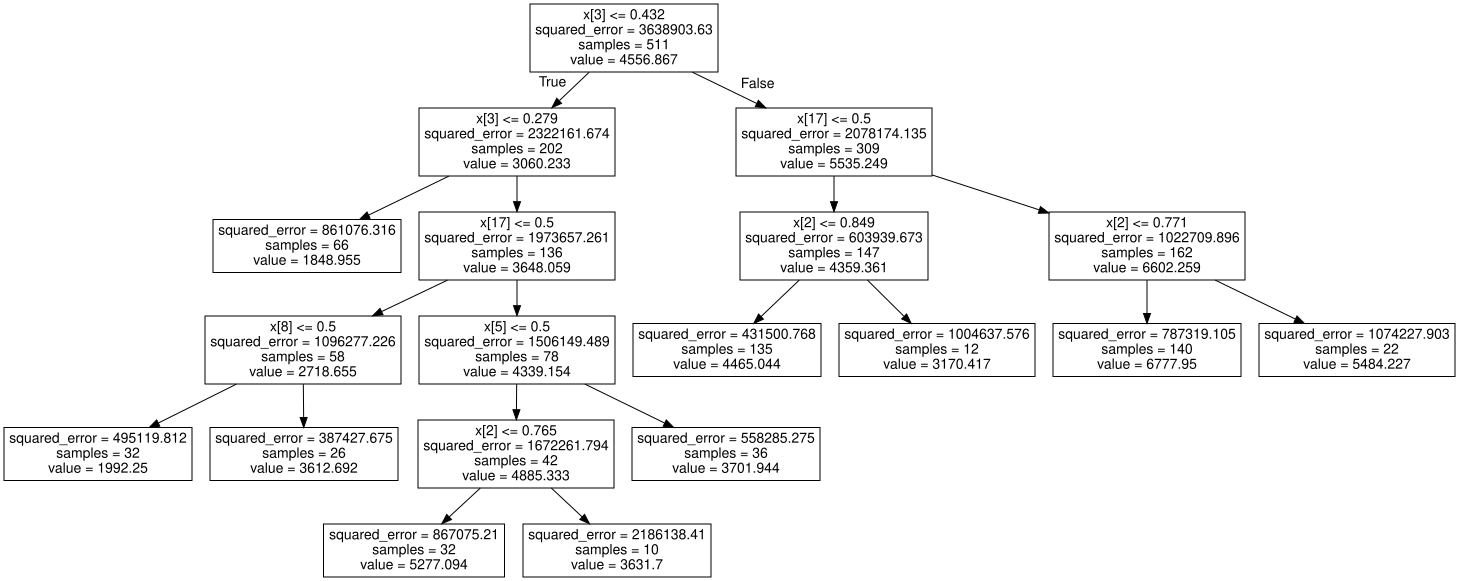

In [ ]:
#Plot the learned model
from sklearn import tree
import pydot
import graphviz

# export the learned model to tree
dot_data = tree.export_graphviz(dtr, out_file=None)
graph = graphviz.Source(dot_data)
graph

In [ ]:
predict=cross_val_predict(dtr,X_train,y_train,cv=3)

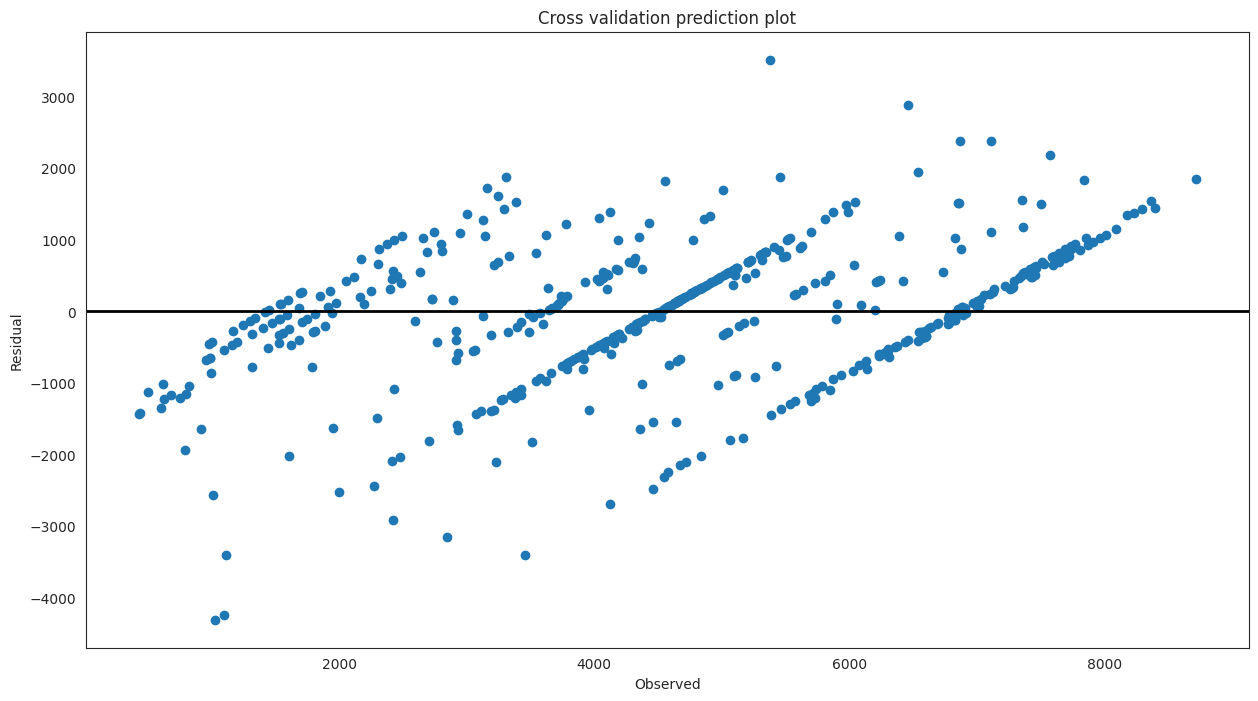

In [ ]:
# Cross validation prediction plot
fig,ax=plt.subplots(figsize=(15,8))
ax.scatter(y_train,y_train-predict)
ax.axhline(lw=2,color='black')
ax.set_title('Cross validation prediction plot')
ax.set_xlabel('Observed')
ax.set_ylabel('Residual')
plt.show()

In [ ]:
# Predict on training data
y_train_pred_dtr = dtr.predict(X_train)

# Calculate metrics for training data
rmse_train_dtr = np.sqrt(metrics.mean_squared_error(y_train, y_train_pred_dtr))
mae_train_dtr = metrics.mean_absolute_error(y_train, y_train_pred_dtr)
r2_train_dtr = metrics.r2_score(y_train, y_train_pred_dtr)

# Predict on test data
y_test_pred_dtr = dtr.predict(X_test)

# Calculate metrics for test data
rmse_test_dtr = np.sqrt(metrics.mean_squared_error(y_test, y_test_pred_dtr))
mae_test_dtr = metrics.mean_absolute_error(y_test, y_test_pred_dtr)
r2_test_dtr = metrics.r2_score(y_test, y_test_pred_dtr)

# Add Decision Tree results to the existing DataFrame
results['DTR_Train'] = [rmse_train_dtr, mae_train_dtr, r2_train_dtr]
results['DTR_Test'] = [rmse_test_dtr, mae_test_dtr, r2_test_dtr]

print("--- Decision Tree Training Data Metrics ---")
print(f"RMSE: {rmse_train_dtr}")
print(f"MAE: {mae_train_dtr}")
print(f"R-squared: {r2_train_dtr}")

print("\n--- Decision Tree Test Data Metrics ---")
print(f"RMSE: {rmse_test_dtr}")
print(f"MAE: {mae_test_dtr}")
print(f"R-squared: {r2_test_dtr}")

print("\nUpdated Results Comparison:")
print(results)


--- Decision Tree Training Data Metrics ---
RMSE: 835.3960054117288
MAE: 638.2618025619738
R-squared: 0.8082151777539757

--- Decision Tree Test Data Metrics ---
RMSE: 925.7976022448886
MAE: 667.8169018859927
R-squared: 0.7845919809904807

Updated Results Comparison:
      Metric    lr_Train     lr_Test  Ridge_Train  Ridge_Test  Lasso_Train  \
0       RMSE  817.147286  783.061697   817.155035  782.846685   817.160251   
1        MAE  585.672049  594.736843   585.660512  594.702898   585.623364   
2  R-squared    0.816503    0.845893     0.816499    0.845978     0.816497   

   Lasso_Test  Ridge_Train_gridCV  Ridge_Test_gridCV  Lasso_Train_gridCV  \
0  782.783378          817.155035         782.846685          817.147354   
1  594.489006          585.660512         594.702898          585.667455   
2    0.846003            0.816499           0.845978            0.816502   

   Lasso_Test_gridCV   DTR_Train    DTR_Test  
0         783.047669  835.396005  925.797602  
1         594.729602

## Random Forest

In [ ]:
#Training the model
from sklearn.ensemble import RandomForestRegressor
X_train=train_encoded_attributes
rf=RandomForestRegressor(n_estimators=600)

In [ ]:
#Fit the trained model
rf.fit(X_train,y_train)

RandomForestRegressor(n_estimators=600)

In [ ]:
import numpy as np
from sklearn import metrics

# Predict on training data
y_train_pred_rf = rf.predict(X_train)

# Calculate metrics for training data
rmse_train_rf = np.sqrt(metrics.mean_squared_error(y_train, y_train_pred_rf))
mae_train_rf = metrics.mean_absolute_error(y_train, y_train_pred_rf)
r2_train_rf = metrics.r2_score(y_train, y_train_pred_rf)

# Predict on test data
y_test_pred_rf = rf.predict(X_test)

# Calculate metrics for test data
rmse_test_rf = np.sqrt(metrics.mean_squared_error(y_test, y_test_pred_rf))
mae_test_rf = metrics.mean_absolute_error(y_test, y_test_pred_rf)
r2_test_rf = metrics.r2_score(y_test, y_test_pred_rf)

# Add Random Forest results to the existing DataFrame
results['RF_Train_600'] = [rmse_train_rf, mae_train_rf, r2_train_rf]
results['RF_Test_600'] = [rmse_test_rf, mae_test_rf, r2_test_rf]

print("--- Random Forest Training Data Metrics ---")
print(f"RMSE: {rmse_train_rf}")
print(f"MAE: {mae_train_rf}")
print(f"R-squared: {r2_train_rf}")

print("\n--- Random Forest Test Data Metrics ---")
print(f"RMSE: {rmse_test_rf}")
print(f"MAE: {mae_test_rf}")
print(f"R-squared: {r2_test_rf}")

print("\nUpdated Results Comparison:")
print(results)


--- Random Forest Training Data Metrics ---
RMSE: 262.2166088987609
MAE: 182.2303392041748
R-squared: 0.9811048719689269

--- Random Forest Test Data Metrics ---
RMSE: 639.6730105423399
MAE: 423.58549242424243
R-squared: 0.8971638479664403

Updated Results Comparison:
      Metric    lr_Train     lr_Test  Ridge_Train  Ridge_Test  Lasso_Train  \
0       RMSE  817.147286  783.061697   817.155035  782.846685   817.160251   
1        MAE  585.672049  594.736843   585.660512  594.702898   585.623364   
2  R-squared    0.816503    0.845893     0.816499    0.845978     0.816497   

   Lasso_Test  Ridge_Train_gridCV  Ridge_Test_gridCV  Lasso_Train_gridCV  ...  \
0  782.783378          817.155035         782.846685          817.147354  ...   
1  594.489006          585.660512         594.702898          585.667455  ...   
2    0.846003            0.816499           0.845978            0.816502  ...   

    DTR_Train    DTR_Test    RF_Train     RF_Test  RF_Train_200  RF_Test_200  \
0  835.396005

## Support Vector Regressor

## KNN regressor

## ADA Boost

## XG Boost